Para imitar fielmente la estructura y la metodología científica del cuaderno Jupyter que adjuntas (el cual consolida todo tu flujo de validación cruzada temporal fija y evaluación métrica de robustez), he adaptado el proceso completo para tu nuevo archivo procesado con componentes principales **con rezagos**.

El script mantiene la arquitectura paramétrica fija original en el bucle iterativo, extrae los valores in-sample y out-of-sample en las tasas de entrenamiento solicitadas en el cuaderno (**95%**, **96%** y **97%**), calcula los errores absolutos medios (MAE) y genera la matriz exacta de gráficos de $3 \times 2$ usando la API orientada a objetos corregida de Matplotlib.

### Script de Validación Cruzada Cronológica (Datos con Rezagos PCA)

```python


[INFO] Cargando espacio muestral desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\2_datos_meteo_epi_con_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx
[INFO] Registros totales identificados: 249 semanas epidemiológicas.
[INFO] Vector exógeno regresor: ['año', 'semana_epi', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5']


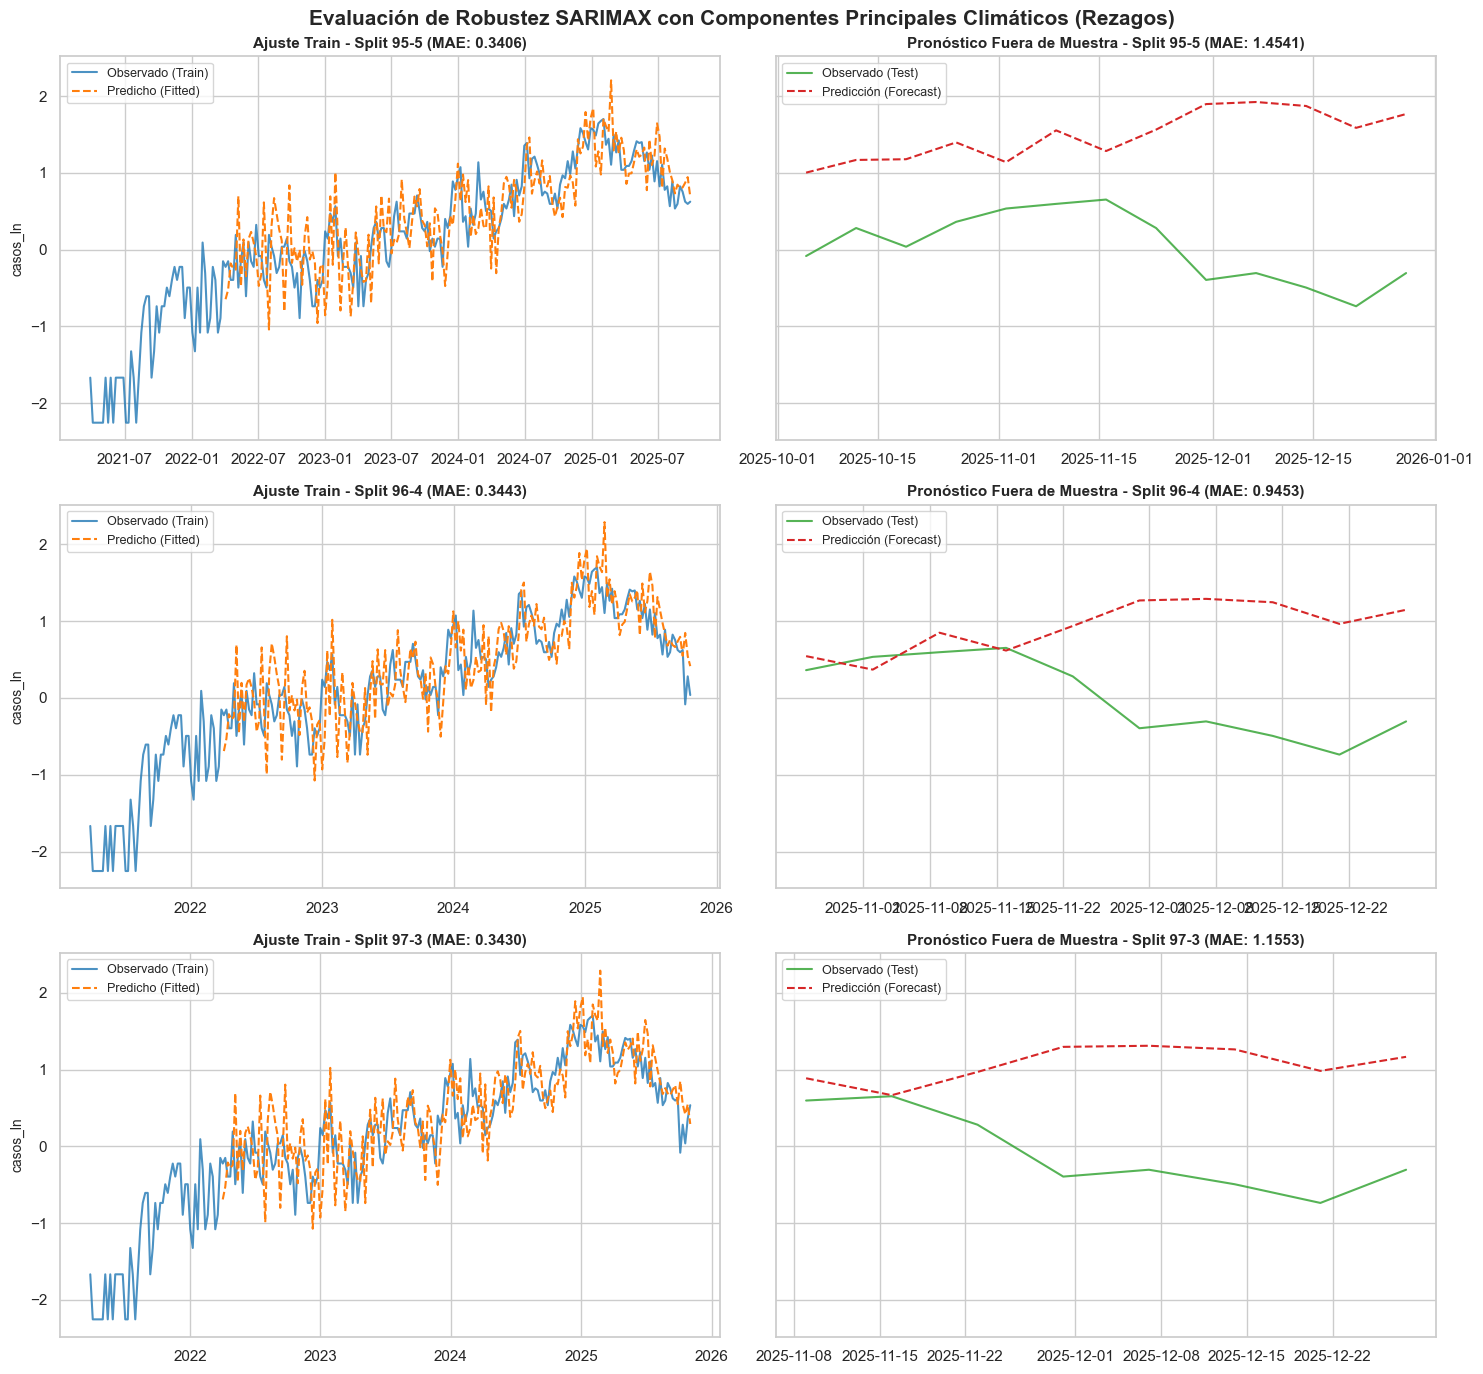


     MÉTRICAS DE RENDIMIENTO GLOBAL DEL MODELO (MAE CON REZAGOS)      
Partición  Soporte Train  Horizonte Test  MAE Train  MAE Test
     95-5            236              13   0.340605  1.454069
     96-4            239              10   0.344314  0.945251
     97-3            241               8   0.342999  1.155266


In [1]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN ESTÍTICA
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DE DATOS (CON REZAGOS Y REDUCCIÓN PCA)
# =============================================================================
# Nueva ubicación especificada por el usuario para los datos procesados con rezagos
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\2_precesados\2_datos_meteo_epi_con_rezagos_escalados_con_pca_a_solo_cinco_dimensiones.xlsx"

print(f"[INFO] Cargando espacio muestral desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)

# Forzar explícitamente la frecuencia semanal para el motor inferencial
df.index.freq = 'W'

# Estructura del modelo determinado en el análisis estocástico original
orden_ordinario = (2, 1, 1)
orden_estacional = (0, 1, 0, 52)
S_ESTACIONAL = 52

# Aislamiento topológico de variables
y = df['casos_ln']
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas]

print(f"[INFO] Registros totales identificados: {len(df)} semanas epidemiológicas.")
print(f"[INFO] Vector exógeno regresor: {columnas_exogenas}")

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES CRONOLÓGICAS (CONFORME AL CUADERNO)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo multipanel (3 filas de tasas x 2 columnas de entornos)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_mae = []

# Bucle de simulación histórica
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    
    # 1. Punto de corte temporal estricto (flecha del tiempo sin data leakage)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    # 2. Ajuste formal del estimador sobre el soporte de entrenamiento
    modelo = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario,
        seasonal_order=orden_estacional,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 3. In-sample forecasting (Ajuste en entrenamiento)
    y_train_pred = modelo.fittedvalues
    # El operador de rezago estacional (1-B^52) pierde los primeros 53 datos por inicialización
    y_train_pred.iloc[:53] = np.nan  
    
    # 4. Out-of-sample dynamic forecasting (Predicción pura en testeo futuro)
    # Se alimenta dinámicamente de las exógenas con rezago de la ventana de validación
    y_test_pred = modelo.forecast(steps=len(y_test), exog=X_test)
    
    # 5. Cálculo del Error Absoluto Medio (MAE)
    mae_train = mean_absolute_error(y_train.dropna()[53:], y_train_pred.dropna())
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Guardar métricas en el histórico tabular
    resultados_mae.append({
        "Partición": nombre_split,
        "Soporte Train": len(y_train),
        "Horizonte Test": len(y_test),
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: CONSTRUCCIÓN DE LA MATRIZ GRÁFICA ORIENTADA A OBJETOS
    # =========================================================================
    # PANEL IZQUIERDO: Comportamiento del ajuste in-sample (Train)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train - Split {nombre_split} (MAE: {mae_train:.4f})", fontsize=11, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # PANEL DERECHO: Comportamiento del pronóstico out-of-sample (Test)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Predicción (Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra - Split {nombre_split} (MAE: {mae_test:.4f})", fontsize=11, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Formatear la superestructura del gráfico multipanel
plt.suptitle('Evaluación de Robustez SARIMAX con Componentes Principales Climáticos (Rezagos)', 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 5: REPORTE DE RESULTADOS ASINTÓTICOS (TABLA COMPARATIVA)
# =============================================================================
df_reporte = pd.DataFrame(resultados_mae)
print("\n" + "="*75)
print("     MÉTRICAS DE RENDIMIENTO GLOBAL DEL MODELO (MAE CON REZAGOS)      ")
print("="*75)
print(df_reporte.to_string(index=False))
print("="*75)



# Elemento clave a observar tras ejecutar este script:

Al comparar los resultados de la tabla impresa por este script frente a los del modelo anterior sin rezagos, debes fijarte en el **`MAE Test`**. Al haber comprimido a través de PCA no solo las variables contemporáneas, sino también sus retrasos en el tiempo, las dimensiones `PC_1` a `PC_5` actuales inyectan memoria física/biológica al sistema (por ejemplo, el efecto rezagado de la lluvia y temperatura sobre la incubación de los vectores). Si el `MAE Test` es inferior en este script, habrás demostrado matemáticamente que las variables climáticas pasadas tienen un efecto causal diferido sobre los casos de estudio.